In [1]:
!pip install scikit-image

In [7]:
import os
import cv2
import timm
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import jaccard_score
from scipy.stats import pearsonr
from skimage.metrics import structural_similarity as ssim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 512

CLASS_NAMES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

BASE_DIR = Path(r"C:\Users\ASUS\OneDrive\Documents\licenta\RetinaXAI")

MODEL_PATH = BASE_DIR / "modelExperiments" / "newCNN" / "best_model_effnetb0_severity.pth"

IMAGE_PATH = BASE_DIR / "data" / "aptos2019-blindness-detection" / "train_images" / "000c1434d8d7.png"

os.makedirs("outputs/xai_metrics", exist_ok=True)

print("Device:", DEVICE)

print(MODEL_PATH)

Device: cpu
C:\Users\ASUS\OneDrive\Documents\licenta\RetinaXAI\modelExperiments\newCNN\best_model_effnetb0_severity.pth


In [8]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=5
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("Model loaded.")

Model loaded.


In [9]:
def preprocess_image(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Image not found: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    original = image.astype(np.float32) / 255.0

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    normalized = (original - mean) / std

    tensor = torch.tensor(normalized, dtype=torch.float32)
    tensor = tensor.permute(2, 0, 1).unsqueeze(0)

    return tensor.to(DEVICE), original

In [10]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()

        score = output[:, class_idx]
        score.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(DEVICE)

        for i, weight in enumerate(weights):
            cam += weight * activations[i]

        cam = torch.relu(cam)
        cam = cam.cpu().numpy()

        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, class_idx


gradcam = GradCAM(model, model.conv_head)

Predicted class: Moderate
Confidence: 0.97625333070755


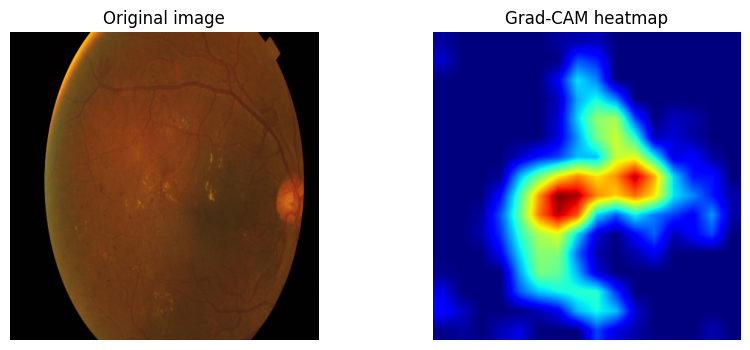

In [11]:
input_tensor, original_image = preprocess_image(IMAGE_PATH)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)[0]
    predicted_class = torch.argmax(probabilities).item()
    original_confidence = probabilities[predicted_class].item()

cam, _ = gradcam.generate(input_tensor, predicted_class)

print("Predicted class:", CLASS_NAMES[predicted_class])
print("Confidence:", original_confidence)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM heatmap")
plt.axis("off")

plt.show()

Original confidence: 0.97625333070755
Masked confidence: 0.7066299319267273
Fidelity score: 0.26962339878082275


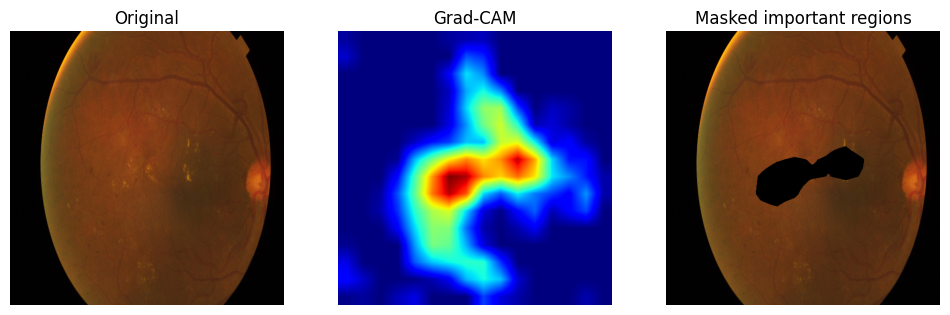

In [12]:
def apply_cam_mask(original_image, cam, threshold=0.7):
    masked_image = original_image.copy()

    important_region = cam >= threshold

    masked_image[important_region] = 0

    return masked_image


def image_to_tensor(image):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    normalized = (image - mean) / std

    tensor = torch.tensor(normalized, dtype=torch.float32)
    tensor = tensor.permute(2, 0, 1).unsqueeze(0)

    return tensor.to(DEVICE)


masked_image = apply_cam_mask(original_image, cam, threshold=0.7)
masked_tensor = image_to_tensor(masked_image)

with torch.no_grad():
    masked_output = model(masked_tensor)
    masked_probabilities = torch.softmax(masked_output, dim=1)[0]
    masked_confidence = masked_probabilities[predicted_class].item()

fidelity_score = original_confidence - masked_confidence

print("Original confidence:", original_confidence)
print("Masked confidence:", masked_confidence)
print("Fidelity score:", fidelity_score)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(masked_image)
plt.title("Masked important regions")
plt.axis("off")

plt.show()

Stability Pearson correlation: -0.47849023
Stability SSIM: 0.14137353463556265


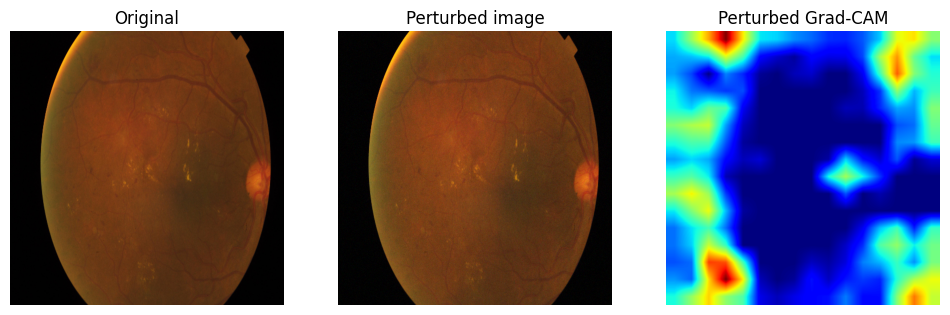

In [13]:
def perturb_image(image):
    perturbed = image.copy()

    # small brightness change
    perturbed = np.clip(perturbed * 1.08, 0, 1)

    # small Gaussian noise
    noise = np.random.normal(0, 0.015, perturbed.shape)
    perturbed = np.clip(perturbed + noise, 0, 1)

    return perturbed


perturbed_image = perturb_image(original_image)
perturbed_tensor = image_to_tensor(perturbed_image)

perturbed_cam, _ = gradcam.generate(perturbed_tensor, predicted_class)

cam_flat = cam.flatten()
perturbed_flat = perturbed_cam.flatten()

pearson_corr, _ = pearsonr(cam_flat, perturbed_flat)

ssim_score = ssim(
    cam,
    perturbed_cam,
    data_range=1.0
)

print("Stability Pearson correlation:", pearson_corr)
print("Stability SSIM:", ssim_score)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(perturbed_image)
plt.title("Perturbed image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(perturbed_cam, cmap="jet")
plt.title("Perturbed Grad-CAM")
plt.axis("off")

plt.show()

In [ ]:
# ==========================================================
# XAI Metrics on Multiple Images
# ==========================================================

from tqdm.notebook import tqdm

N_IMAGES = 50

metrics_results = []

sample_df = pd.read_csv(BASE_DIR / "data" / "aptos2019-blindness-detection" / "train.csv")
image_dir = BASE_DIR / "data" / "aptos2019-blindness-detection" / "train_images"

# sample stratified-ish: ia câteva imagini din fiecare clasă
sample_df = sample_df.groupby("diagnosis", group_keys=False).apply(
    lambda x: x.sample(min(len(x), N_IMAGES // 5), random_state=42)
)

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    image_path = image_dir / f"{row['id_code']}.png"

    input_tensor, original_image = preprocess_image(image_path)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0]
        predicted_class = torch.argmax(probs).item()
        original_confidence = probs[predicted_class].item()

    cam, _ = gradcam.generate(input_tensor, predicted_class)

    # ---------- Fidelity ----------
    masked_image = apply_cam_mask(original_image, cam, threshold=0.7)
    masked_tensor = image_to_tensor(masked_image)

    with torch.no_grad():
        masked_output = model(masked_tensor)
        masked_probs = torch.softmax(masked_output, dim=1)[0]
        masked_confidence = masked_probs[predicted_class].item()

    fidelity_score = original_confidence - masked_confidence

    # ---------- Stability ----------
    perturbed_image = perturb_image(original_image)
    perturbed_tensor = image_to_tensor(perturbed_image)

    perturbed_cam, _ = gradcam.generate(perturbed_tensor, predicted_class)

    # normalize heatmaps before comparison
    cam_norm = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    perturbed_norm = (perturbed_cam - perturbed_cam.min()) / (perturbed_cam.max() - perturbed_cam.min() + 1e-8)

    try:
        pearson_corr, _ = pearsonr(cam_norm.flatten(), perturbed_norm.flatten())
    except:
        pearson_corr = np.nan

    ssim_score = ssim(cam_norm, perturbed_norm, data_range=1.0)

    metrics_results.append({
        "image_id": row["id_code"],
        "true_label": int(row["diagnosis"]),
        "predicted_label": predicted_class,
        "predicted_class_name": CLASS_NAMES[predicted_class],
        "original_confidence": original_confidence,
        "masked_confidence": masked_confidence,
        "fidelity_score": fidelity_score,
        "stability_pearson": pearson_corr,
        "stability_ssim": ssim_score
    })

metrics_df = pd.DataFrame(metrics_results)

metrics_df.to_csv("outputs/xai_metrics/xai_metrics_multiple_images.csv", index=False)

metrics_df

In [ ]:
# ==========================================================
# XAI Metrics Summary
# ==========================================================

summary = metrics_df[
    [
        "fidelity_score",
        "stability_pearson",
        "stability_ssim"
    ]
].mean()

print("Average Fidelity:", summary["fidelity_score"])
print("Average Stability Pearson:", summary["stability_pearson"])
print("Average Stability SSIM:", summary["stability_ssim"])

metrics_df.groupby("true_label")[
    [
        "fidelity_score",
        "stability_pearson",
        "stability_ssim"
    ]
].mean()

In [14]:
results = {
    "image_path": str(IMAGE_PATH),
    "predicted_class": CLASS_NAMES[predicted_class],
    "original_confidence": original_confidence,
    "masked_confidence": masked_confidence,
    "fidelity_score": fidelity_score,
    "stability_pearson": pearson_corr,
    "stability_ssim": ssim_score
}

# Adaugă HA doar dacă ai doctor_mask
try:
    results["human_alignment_iou"] = iou_score
    results["human_alignment_dice"] = dice_score
    results["human_alignment_overlap"] = overlap_percentage
except NameError:
    results["human_alignment_iou"] = None
    results["human_alignment_dice"] = None
    results["human_alignment_overlap"] = None

df_results = pd.DataFrame([results])

df_results.to_csv("outputs/xai_metrics/xai_metrics_results.csv", index=False)

df_results

,image_path,predicted_class,original_confidence,masked_confidence,fidelity_score,stability_pearson,stability_ssim,human_alignment_iou,human_alignment_dice,human_alignment_overlap
0,C:\Users\ASUS\OneDrive\Documents\licenta\Retin...,Moderate,0.976253,0.70663,0.269623,-0.47849,0.141374,None,None,None
